In [1]:
import sys,os
import numpy as np
import pydicom as dcm
import matplotlib.pyplot as plt

## Using functions from longiDICOM

In [2]:
# loading functions from modules (from another location, might need to do ../longiDICOM/code, or something
sys.path.append('../code')
from RD_tools import find_dose_file, get_dose_in_gy, get_dose_xyz, get_dose_spacing, resample_dose_map_3D, resize_dose_map_3D, get_struct_dose_values, create_binary_mask, extract_dose_values
from rs_tools import find_RS_file, find_ROI_names

# Basic DICOM Loading

In [13]:
path_to_ct = '/mnt/iDriveShare/Kayla/CBCT_images/kayla_extracted/1288/20200916_CT_11_SEP_2020/' # Path to all CT, RD, RS, etc...

## Image Slices

In [14]:
# Load CT:
slices = [dcm.read_file(path_to_ct+ s) for s in os.listdir(path_to_ct) if 'CT' in s] # Assumes each CT file starts with 'CT', adjust accordingly
slices.sort(key = lambda x: (x.InstanceNumber)) # Sort by the instance number in the DICOM tag 
# Note: the isntance number should be in the correct slice order (1,2...N). 
#If it is not, you will need to sort based on the 'z' value in the ImagePositionPatient tag

# Image Sacping Parameters
CT_origin = slices[0].ImagePositionPatient
pixel_spacing = slices[0].PixelSpacing
CT_spacing = [pixel_spacing[0],pixel_spacing[1],slices[0].SliceThickness]

Displaying slice 60 out of 127


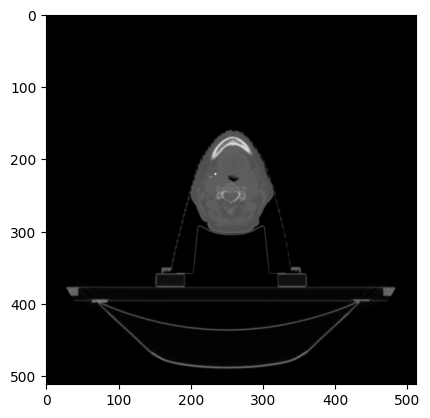

In [15]:
# View an image slice
slice_num = 60

plt.imshow(slices[slice_num].pixel_array, cmap='gray') # Here, it is slice 60. 

print("Displaying slice", slice_num, "out of", len(slices))

In [16]:
# ADD 3 VIEWS

## DICOM RT DOSE
### See "Sample Notebook - RT Dose.ipynb" 

## DICOM RT PLAN

In [26]:
RP_file = os.path.join(path_to_ct,[x for x in os.listdir(path_to_ct) if 'RP' in x][0]) # file path to RP file

RP = dcm.read_file(RP_file) # Read file

In [27]:
# print(RP) #uncomment to print entire file

In [51]:
# everything is text based and needs to be accessed via nested tags
# Note for VMAT, there are many control points along the arc path, showing snapshots of the movement 



In [39]:
# Example: Basic Plan information
fx_data = RP.FractionGroupSequence[0] 
print("Num. Planned fractions:",fx_data.NumberOfFractionsPlanned)
print("Num. Beams:",fx_data.NumberOfBeams)

Num. Planned fractions: 21
Num. Beams: 7


In [50]:
# Note some beams maybe imaging beams (not treatment)
#e.g.:
print("Beam names")
for beam in RP.BeamSequence: # cycle through each beam
    print("Beam #",beam.BeamNumber, ":",beam.BeamName )


# CBCT, ANT Setup, RT LAT Setup, and LT LAT Setup are all imaging fields

print("_________________________________")
# You can also check if a dose was given by the beam, if none, it is not a treatment beam
for beam_ref in RP.FractionGroupSequence[0].ReferencedBeamSequence:
    print("Beam Number:", beam_ref.ReferencedBeamNumber)
    try:
        beam_dose = beam_ref.BeamDose
        print("         Dose given by this beam:",beam_dose)
    except:
        print("         No dose (not a treatment field)")

# Notice beams are cross referenced in various parts of the dicom tags with their number

Beam names
Beam # 1 : M1-1.1ARC1
Beam # 2 : M1-1.2ARC2
Beam # 3 : M1-1.3ARC3
Beam # 5 : CBCT
Beam # 6 : ANT Setup
Beam # 7 : RT LAT Setup
Beam # 4 : LT LAT Setup
_________________________________
Beam Number: 1
         Dose given by this beam: 0.82951478911742
Beam Number: 2
         Dose given by this beam: 0.66665554094528
Beam Number: 3
         Dose given by this beam: 0.50382966993731
Beam Number: 5
         No dose (not a treatment field)
Beam Number: 6
         No dose (not a treatment field)
Beam Number: 7
         No dose (not a treatment field)
Beam Number: 4
         No dose (not a treatment field)


In [66]:
# Example Gantry angle 
# For first beam (arc) 
for beam in RP.BeamSequence:
    print("--------------------------------------")
    print("Beam Number:", beam.BeamNumber)
    print("Delivery type:", beam.TreatmentDeliveryType) # here you can also see fi the type is TREATMENT or SETUP (imaging)
    beam_type = beam.BeamType
    print("Beam Type:", beam_type) #Static = one angle (simpler), dynamic = moving arc (many control points)
    print("Control points:", beam.NumberOfControlPoints)
    
    control_pts = beam.ControlPointSequence
    print("Start Angle:", control_pts[0].GantryAngle)
    if beam_type == 'DYNAMIC':
        print("Stop Angle:", control_pts[-1].GantryAngle)
        print("Direction:",control_pts[0].GantryRotationDirection  )

--------------------------------------
Beam Number: 1
Delivery type: TREATMENT
Beam Type: DYNAMIC
Control points: 114
Start Angle: 181
Stop Angle: 15
Direction: CW
--------------------------------------
Beam Number: 2
Delivery type: TREATMENT
Beam Type: DYNAMIC
Control points: 114
Start Angle: 15
Stop Angle: 181
Direction: CC
--------------------------------------
Beam Number: 3
Delivery type: TREATMENT
Beam Type: DYNAMIC
Control points: 114
Start Angle: 181
Stop Angle: 15
Direction: CW
--------------------------------------
Beam Number: 5
Delivery type: SETUP
Beam Type: STATIC
Control points: 2
Start Angle: 0
--------------------------------------
Beam Number: 6
Delivery type: SETUP
Beam Type: STATIC
Control points: 2
Start Angle: 0
--------------------------------------
Beam Number: 7
Delivery type: SETUP
Beam Type: STATIC
Control points: 2
Start Angle: 270
--------------------------------------
Beam Number: 4
Delivery type: SETUP
Beam Type: STATIC
Control points: 2
Start Angle: 90
